# Optimisation de Portefeuille Bayésien — Black-Litterman
**Groupe 03 | ECE Paris 2026**

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config

from data import download_prices, compute_returns
from stats import compute_mean_returns, compute_cov_matrix
from markowitz import markowitz_weights, efficient_frontier, market_cap_weights
from black_litterman import compute_equilibrium_returns, build_views, compute_omega, black_litterman_posterior, optimize_bl_portfolio
from ml_views import generate_momentum_views
from backtest import backtest_bl

# Tout vient de config.py — modifie config.py pour tout changer
TICKERS = config.TICKERS
START   = config.START
END     = config.END
COLORS  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"Periode : {START} -> {END}")
print(f"Actifs  : {TICKERS}")

Periode : 2023-01-01 -> 2026-03-28
Actifs  : ['AAPL', 'MSFT', 'GOOGL', 'META', 'AMZN']


In [2]:
prices    = download_prices(TICKERS, START, END)
returns   = compute_returns(prices)
mu        = compute_mean_returns(returns)
cov       = compute_cov_matrix(returns)
mw        = market_cap_weights(TICKERS, prices)
pi        = compute_equilibrium_returns(cov, mw)
result_mw = markowitz_weights(mu, cov, max_weight=config.MAX_WEIGHT)

# Views : manuelles si definies dans config.py, sinon momentum auto
if config.VIEWS:
    views       = config.VIEWS
    confidences = config.CONFIDENCES
else:
    views       = generate_momentum_views(prices, lookback=config.MOMENTUM_LOOKBACK)
    confidences = [0.65] * len(views)

# Securite : si toujours vide, on ne peut pas continuer
if not views:
    raise ValueError("Aucune view generee. Ajoute des views dans config.py ou elargis le lookback momentum.")

P, Q          = build_views(TICKERS, views)
omega         = compute_omega(P, cov, confidences=confidences)
mu_bl, cov_bl = black_litterman_posterior(pi, cov, P, Q, omega)
result_bl     = optimize_bl_portfolio(mu_bl, cov_bl, max_weight=config.MAX_WEIGHT)

print("Donnees chargees.")
print(f"{len(views)} view(s) appliquee(s)")


Donnees chargees.
4 view(s) appliquee(s)


## Graphique 1 — Evolution des prix (base 100)

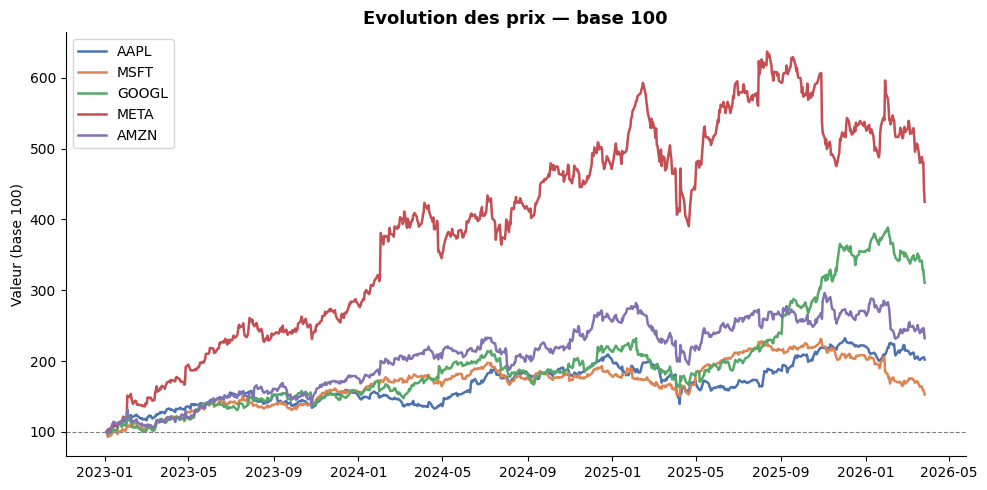

In [3]:
fig, ax = plt.subplots()
normalized = prices / prices.iloc[0] * 100
for i, ticker in enumerate(TICKERS):
    ax.plot(normalized.index, normalized[ticker], label=ticker, color=COLORS[i], linewidth=1.8)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Evolution des prix — base 100', fontsize=13, fontweight='bold')
ax.set_ylabel('Valeur (base 100)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Graphique 2 — Allocation : Markowitz vs Black-Litterman

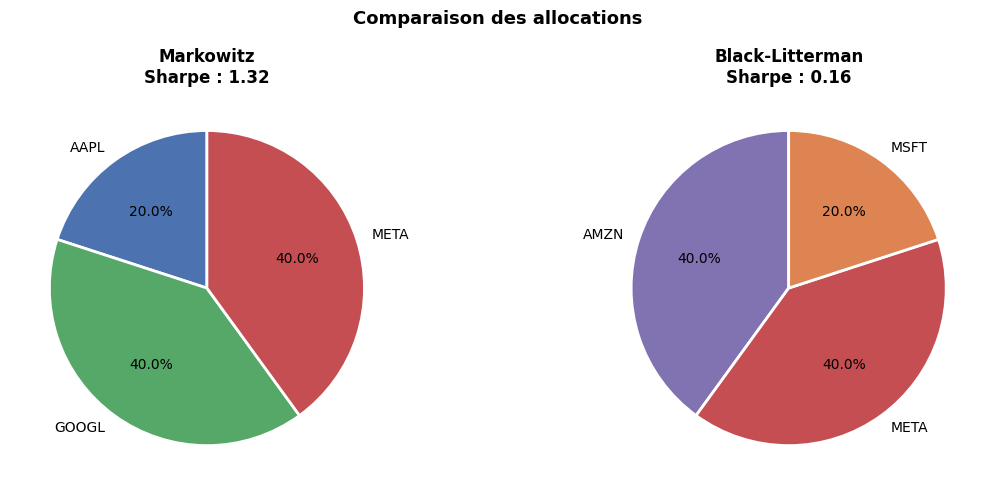

           Markowitz Black-Litterman
Rendement     36.47%           6.64%
Volatilité    26.12%          28.25%
Sharpe          1.32            0.16


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, result, title in [
    (axes[0], result_mw, f"Markowitz\nSharpe : {result_mw['sharpe']:.2f}"),
    (axes[1], result_bl, f"Black-Litterman\nSharpe : {result_bl['sharpe']:.2f}"),
]:
    w = result['weights']
    sig = w[w > 0.01]
    ax.pie(sig, labels=sig.index, autopct='%1.1f%%',
           colors=[COLORS[TICKERS.index(t)] for t in sig.index],
           startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(title, fontsize=12, fontweight='bold')
plt.suptitle('Comparaison des allocations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

recap = pd.DataFrame({
    'Markowitz':       [f"{result_mw['return']:.2%}", f"{result_mw['volatility']:.2%}", f"{result_mw['sharpe']:.2f}"],
    'Black-Litterman': [f"{result_bl['return']:.2%}", f"{result_bl['volatility']:.2%}", f"{result_bl['sharpe']:.2f}"],
}, index=['Rendement', 'Volatilité', 'Sharpe'])
print(recap)

## Graphique 3 — Frontière Efficiente

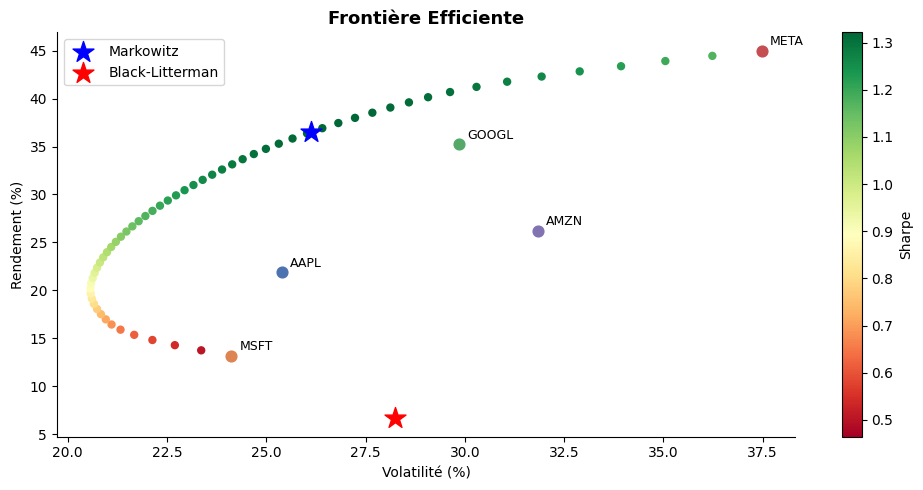

In [5]:
frontier = efficient_frontier(mu, cov, n_points=60)

fig, ax = plt.subplots()
sc = ax.scatter(frontier['volatility']*100, frontier['return']*100,
                c=frontier['sharpe'], cmap='RdYlGn', s=25, zorder=2)
plt.colorbar(sc, ax=ax, label='Sharpe')
ax.scatter(result_mw['volatility']*100, result_mw['return']*100,
           marker='*', s=250, color='blue', zorder=5, label='Markowitz')
ax.scatter(result_bl['volatility']*100, result_bl['return']*100,
           marker='*', s=250, color='red', zorder=5, label='Black-Litterman')
for i, ticker in enumerate(TICKERS):
    ax.scatter(np.sqrt(cov.loc[ticker, ticker])*100, mu[ticker]*100,
               color=COLORS[i], s=60, zorder=4)
    ax.annotate(ticker, (np.sqrt(cov.loc[ticker, ticker])*100, mu[ticker]*100),
                textcoords='offset points', xytext=(6, 4), fontsize=9)
ax.set_xlabel('Volatilité (%)')
ax.set_ylabel('Rendement (%)')
ax.set_title('Frontière Efficiente', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Graphique 4 — Backtesting

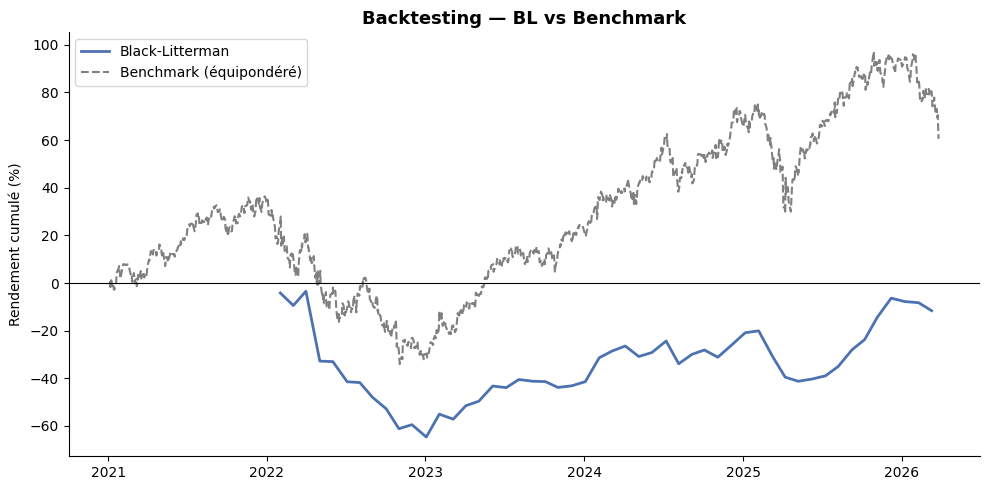

Périodes testées     : 50
Rendement cumulé BL  : -11.60%
Rendement moyen/mois : +0.23%


In [6]:
from datetime import date
START_BT  = f"{date.today().year - 5}-01-01"
prices_bt = download_prices(TICKERS, START_BT, END)
mw_bt     = market_cap_weights(TICKERS, prices_bt)
bt        = backtest_bl(prices_bt, mw_bt, generate_momentum_views)

returns_bt   = compute_returns(prices_bt)
bench_cumret = (1 + returns_bt.mean(axis=1)).cumprod() - 1

fig, ax = plt.subplots()
if not bt.empty:
    ax.plot(bt['date'], bt['cumulative_return']*100,
            label='Black-Litterman', color='#4C72B0', linewidth=2)
ax.plot(bench_cumret.index, bench_cumret*100,
        label='Benchmark (équipondéré)', color='gray', linewidth=1.5, linestyle='--')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Rendement cumulé (%)')
ax.set_title('Backtesting — BL vs Benchmark', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

if not bt.empty:
    print(f"Périodes testées     : {len(bt)}")
    print(f"Rendement cumulé BL  : {bt['cumulative_return'].iloc[-1]:+.2%}")
    print(f"Rendement moyen/mois : {bt['portfolio_return'].mean():+.2%}")

## Graphique 5 — Prior vs Posterior (impact des views)

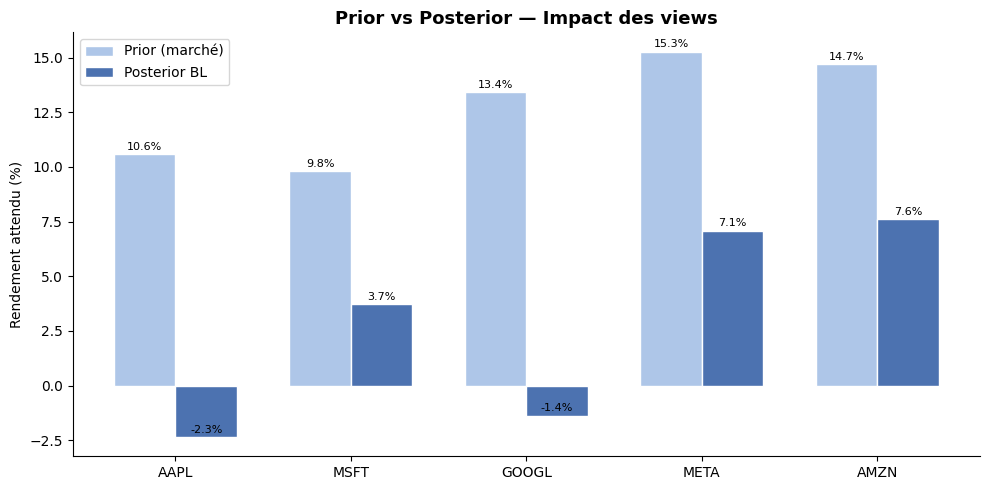

Views appliquées (momentum automatique) :
  AAPL   → -5.00%
  META   → +8.00%
  GOOGL  → -10.00%
  MSFT   → +16.00%


In [7]:
x = range(len(TICKERS))
width = 0.35

fig, ax = plt.subplots()
b1 = ax.bar([i - width/2 for i in x], pi.reindex(TICKERS)*100,
            width, label='Prior (marché)', color='#AEC6E8', edgecolor='white')
b2 = ax.bar([i + width/2 for i in x], mu_bl.reindex(TICKERS)*100,
            width, label='Posterior BL',  color='#4C72B0', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(TICKERS)
ax.set_ylabel('Rendement attendu (%)')
ax.set_title('Prior vs Posterior — Impact des views', fontsize=13, fontweight='bold')
ax.legend()

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print('Views appliquées (momentum automatique) :')
for v in views:
    print(f"  {v['asset']:6s} → {v['return']:+.2%}")

## Graphique 6 — Sensibilité aux views

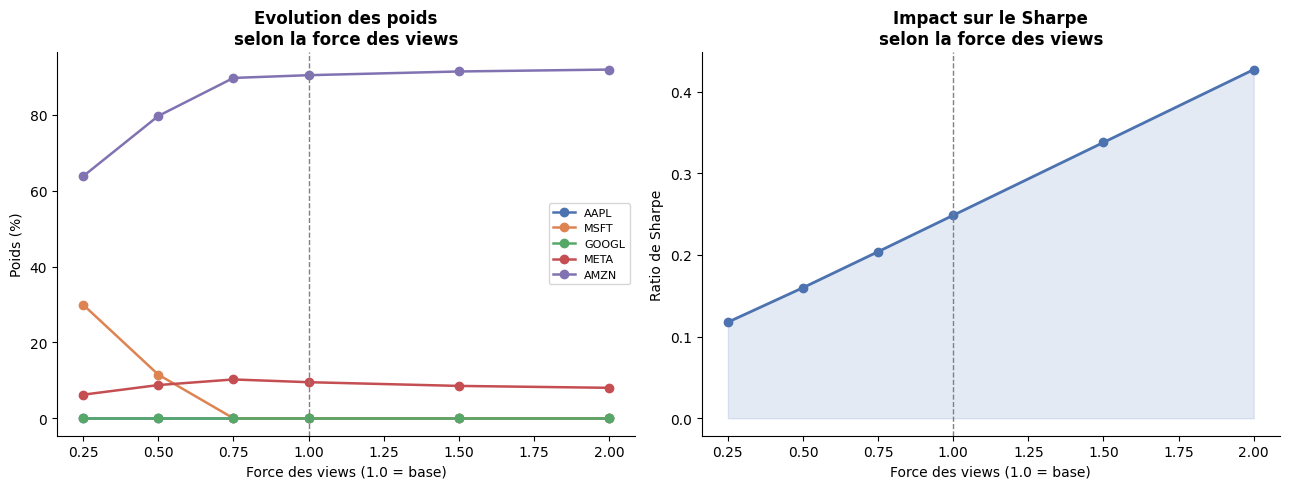

In [8]:
from backtest import sensitivity_analysis

perturbations = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
sensitivity   = sensitivity_analysis(pi, cov, P, Q, mw, perturbations=perturbations)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for i, ticker in enumerate(TICKERS):
    if ticker in sensitivity.columns:
        ax1.plot(sensitivity.index, sensitivity[ticker]*100,
                 marker='o', label=ticker, color=COLORS[i], linewidth=1.8)
ax1.axvline(1.0, color='gray', linestyle='--', linewidth=1)
ax1.set_xlabel('Force des views (1.0 = base)')
ax1.set_ylabel('Poids (%)')
ax1.set_title('Evolution des poids\nselon la force des views', fontweight='bold')
ax1.legend(fontsize=8)

ax2.plot(sensitivity.index, sensitivity['sharpe'],
         marker='o', color='#4C72B0', linewidth=2)
ax2.fill_between(sensitivity.index, sensitivity['sharpe'], alpha=0.15, color='#4C72B0')
ax2.axvline(1.0, color='gray', linestyle='--', linewidth=1)
ax2.set_xlabel('Force des views (1.0 = base)')
ax2.set_ylabel('Ratio de Sharpe')
ax2.set_title('Impact sur le Sharpe\nselon la force des views', fontweight='bold')

plt.tight_layout()
plt.show()